In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "NYK"
away= "WAS"

In [3]:
game_day = datetime.strptime("2025-03-02", "%Y-%m-%d")

In [4]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,MP,Tm_FG,Tm_FGA,...,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pos,Tm_Pace,Opp_Pace
64,NYK,POR,2025-03-12,W,A,114,113,265,44,94,...,12.7,50.0,5.9,9.5,19.8,2.0,2.0,102.275000,92.626415,92.626415
65,NYK,GSW,2025-03-15,L,A,94,97,240,37,86,...,12.4,75.8,7.7,8.1,10.6,3.0,2.0,90.590985,90.590985,90.590985
66,NYK,MIA,2025-03-17,W,H,116,95,240,47,95,...,12.5,59.0,9.4,9.8,19.4,2.0,2.0,96.254425,96.254425,96.254425
67,NYK,SAS,2025-03-19,L,A,105,120,240,39,92,...,9.8,62.2,7.4,12.7,13.2,2.0,2.0,94.673400,94.673400,94.673400
68,NYK,CHO,2025-03-20,L,A,98,115,240,36,90,...,6.6,58.1,1.1,5.9,11.2,1.0,2.0,94.079175,94.079175,94.079175


In [5]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,MP,Tm_FG,Tm_FGA,...,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pos,Tm_Pace,Opp_Pace
64,POR,NYK,2025-03-12,L,H,113,114,265,40,90,...,19.8,61.4,11.7,14.6,12.7,2.0,2.0,102.275000,92.626415,92.626415
65,GSW,NYK,2025-03-15,W,H,97,94,240,33,83,...,10.6,54.1,6.6,14.3,12.4,2.0,3.0,90.590985,90.590985,90.590985
66,MIA,NYK,2025-03-17,L,A,95,116,240,39,82,...,19.4,63.8,12.5,10.2,12.5,2.0,2.0,96.254425,96.254425,96.254425
67,SAS,NYK,2025-03-19,W,H,120,105,240,45,90,...,13.2,71.8,7.4,12.7,9.8,2.0,2.0,94.673400,94.673400,94.673400
68,CHO,NYK,2025-03-20,W,H,115,98,240,43,88,...,11.2,72.2,9.6,3.6,6.6,2.0,1.0,94.079175,94.079175,94.079175


In [6]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,MP,Tm_FG,Tm_FGA,...,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pos,Tm_Pace,Opp_Pace
64,WAS,DET,2025-03-13,W,A,129,125,240,43,90,...,13.6,59.0,7.6,13.3,10.4,2.0,2.0,104.691930,104.691930,104.691930
65,WAS,DEN,2025-03-15,W,A,126,123,240,46,95,...,14.2,83.3,11.4,16.0,14.9,2.0,1.0,105.588485,105.588485,105.588485
66,WAS,POR,2025-03-17,L,A,97,112,240,38,92,...,14.1,59.5,15.1,5.8,7.7,2.0,1.0,99.236585,99.236585,99.236585
67,WAS,UTA,2025-03-19,L,A,112,128,240,43,93,...,12.2,60.0,7.0,2.1,14.9,2.0,2.0,100.433605,100.433605,100.433605
68,WAS,ORL,2025-03-21,L,H,105,120,240,37,87,...,13.6,54.3,9.0,16.7,11.3,2.0,2.0,100.049750,100.049750,100.049750


In [7]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,MP,Tm_FG,Tm_FGA,...,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pos,Tm_Pace,Opp_Pace
64,DET,WAS,2025-03-13,L,H,125,129,240,39,85,...,10.4,69.8,9.6,9.1,13.6,2.0,2.0,104.691930,104.691930,104.691930
65,DEN,WAS,2025-03-15,L,H,123,126,240,48,95,...,14.9,73.9,10.4,6.6,14.2,1.0,2.0,105.588485,105.588485,105.588485
66,POR,WAS,2025-03-17,W,H,112,97,240,42,99,...,7.7,71.1,6.0,13.2,14.1,1.0,2.0,99.236585,99.236585,99.236585
67,UTA,WAS,2025-03-19,W,H,128,112,240,50,89,...,14.9,69.8,11.9,8.5,12.2,2.0,2.0,100.433605,100.433605,100.433605
68,ORL,WAS,2025-03-21,W,A,120,105,240,46,96,...,11.3,62.2,11.0,7.4,13.6,2.0,2.0,100.049750,100.049750,100.049750


In [8]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'Tm_PTS', 'Opp_PTS', 'MP', 'Tm_FG', 'Tm_FGA', 'Tm_FG%', 'Tm_2P', 'Tm_2PA', 'Tm_2P%', 'Tm_3P', 'Tm_3PA', 'Tm_3P%', 'Tm_FT', 'Tm_FTA', 'Tm_FT%', 'Opp_FG', 'Opp_FGA', 'Opp_FG%', 'Opp_2P', 'Opp_2PA', 'Opp_2P%', 'Opp_3P', 'Opp_3PA', 'Opp_3P%', 'Opp_FT', 'Opp_FTA', 'Opp_FT%', 'Tm_ORB', 'Tm_DRB', 'Tm_TRB', 'Opp_ORB', 'Opp_DRB', 'Opp_TRB', 'Tm_AST', 'Tm_STL', 'Tm_BLK', 'Tm_TOV', 'Tm_PF', 'Opp_AST', 'Opp_STL', 'Opp_BLK', 'Opp_TOV', 'Opp_PF', 'Tm_ORtg', 'Tm_DRtg', 'Tm_FTr', 'Tm_3PAr', 'Tm_TS%', 'Tm_eFG%', 'Tm_FT/FGA', 'Opp_ORtg', 'Opp_DRtg', 'Opp_FTr', 'Opp_3PAr', 'Opp_TS%', 'Opp_eFG%', 'Opp_FT/FGA', 'Tm_ORB%', 'Tm_DRB%', 'Tm_TRB%', 'Opp_ORB%', 'Opp_DRB%', 'Opp_TRB%', 'Tm_AST%', 'Tm_STL%', 'Tm_BLK%', 'Tm_TOV%', 'Opp_AST%', 'Opp_STL%', 'Opp_BLK%', 'Opp_TOV%', 'Tm_Rest', 'Opp_Rest', 'Tm_Pos', 'Tm_Pace', 'Opp_Pace']


# Desc

# Features

## Offense

In [9]:
offense= ['Tm_PTS', 'Tm_FGA', 'Tm_FG%', 'Tm_2PA', 'Tm_2P%', 'Tm_3PA', 'Tm_3P%', 'Tm_FTA', 'Tm_FT%', 'Tm_ORB', 'Tm_AST', 'Tm_TOV',
          'Tm_ORtg', 'Tm_FTr', 'Tm_3PAr', 'Tm_TS%', 'Tm_eFG%', 'Tm_FT/FGA', 'Tm_ORB%','Tm_AST%', 'Opp_DRB', 'Opp_STL', 'Opp_BLK', 
          'Opp_DRtg', 'Opp_DRB%', 'Opp_STL%', 'Opp_BLK%', 'Opp_TOV%', 'Tm_Pace']

In [10]:
df_home_off= df_home[offense]
df_home_off.head()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Tm_AST%,Opp_DRB,Opp_STL,Opp_BLK,Opp_DRtg,Opp_DRB%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Pace
0,109,78,0.551,48,0.667,30,0.367,16,0.750,5,...,46.5,29,6,3,121.6,85.3,6.7,6.3,3.9,89.632550
1,123,84,0.524,57,0.561,27,0.444,29,0.793,11,...,43.2,24,8,6,128.6,68.6,8.4,10.5,14.8,95.637000
2,104,90,0.444,62,0.500,28,0.321,18,0.833,13,...,55.0,32,10,5,107.9,71.1,10.4,8.1,13.1,96.355095
3,116,82,0.488,42,0.524,40,0.450,20,0.900,7,...,75.0,32,6,3,124.9,82.1,6.5,7.1,9.8,92.846690
4,128,101,0.515,63,0.540,38,0.474,10,0.600,12,...,59.6,32,6,9,128.1,72.7,6.0,14.3,20.7,99.947705


In [11]:
df_home_off.columns

Index(['Tm_PTS', 'Tm_FGA', 'Tm_FG%', 'Tm_2PA', 'Tm_2P%', 'Tm_3PA', 'Tm_3P%',
       'Tm_FTA', 'Tm_FT%', 'Tm_ORB', 'Tm_AST', 'Tm_TOV', 'Tm_ORtg', 'Tm_FTr',
       'Tm_3PAr', 'Tm_TS%', 'Tm_eFG%', 'Tm_FT/FGA', 'Tm_ORB%', 'Tm_AST%',
       'Opp_DRB', 'Opp_STL', 'Opp_BLK', 'Opp_DRtg', 'Opp_DRB%', 'Opp_STL%',
       'Opp_BLK%', 'Opp_TOV%', 'Tm_Pace'],
      dtype='object')

In [12]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.head()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Tm_AST%,Opp_DRB,Opp_STL,Opp_BLK,Opp_DRtg,Opp_DRB%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Pace
0,132,95,0.505,34,0.559,61,0.475,8,0.875,11,...,68.8,29,2,3,147.3,72.5,2.2,8.8,12.4,89.632550
1,98,83,0.494,53,0.717,30,0.100,20,0.650,9,...,68.3,32,5,4,102.5,78.0,5.2,7.5,11.0,95.637000
2,110,82,0.476,46,0.587,36,0.333,24,0.833,9,...,53.8,30,8,3,114.2,76.9,8.3,6.5,14.0,96.355095
3,107,81,0.457,41,0.488,40,0.425,24,0.667,7,...,73.0,35,8,4,115.2,83.3,8.6,9.8,10.8,92.846690
4,98,81,0.506,47,0.638,34,0.324,7,0.714,6,...,56.1,33,16,3,98.0,84.6,16.0,6.4,8.7,99.947705


In [13]:
df_away_off= df_away[offense]
df_away_off.head()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Tm_AST%,Opp_DRB,Opp_STL,Opp_BLK,Opp_DRtg,Opp_DRB%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Pace
0,102,95,0.432,59,0.576,36,0.194,18,0.722,10,...,65.9,37,7,3,99.5,78.7,6.8,5.1,12.1,102.501950
1,116,96,0.385,53,0.415,43,0.349,32,0.844,18,...,67.6,37,13,10,110.8,67.3,12.4,18.9,14.2,104.692575
2,121,91,0.451,47,0.426,44,0.477,22,0.818,9,...,58.5,33,12,7,114.7,78.6,11.4,14.9,14.2,105.505000
3,133,89,0.528,51,0.608,38,0.421,25,0.920,6,...,68.1,29,10,3,125.0,82.9,9.4,5.9,14.0,106.394380
4,98,91,0.418,56,0.554,35,0.200,21,0.714,8,...,60.5,44,6,3,95.6,84.6,5.9,5.4,11.1,102.517410


In [14]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.head()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Tm_AST%,Opp_DRB,Opp_STL,Opp_BLK,Opp_DRtg,Opp_DRB%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Pace
0,122,90,0.467,45,0.556,45,0.378,27,0.778,12,...,50.0,30,9,6,119.0,71.4,8.8,13.3,12.7,102.501950
1,135,88,0.534,49,0.592,39,0.462,34,0.676,11,...,57.4,28,6,9,129.0,71.8,5.7,18.4,12.0,104.692575
2,119,81,0.481,41,0.585,40,0.375,36,0.722,6,...,82.1,34,7,3,112.8,85.0,6.6,7.3,15.2,105.505000
3,120,95,0.474,56,0.589,39,0.308,21,0.857,12,...,62.2,31,10,5,112.8,72.1,9.4,8.9,13.8,106.394380
4,118,102,0.422,65,0.431,37,0.405,24,0.708,21,...,44.2,36,12,10,115.1,63.2,11.7,15.4,10.7,102.517410


## Defence

In [15]:
defence= ['Tm_DRB', 'Tm_STL', 'Tm_BLK', 'Tm_DRtg', 'Tm_DRB%', 'Tm_STL%', 'Tm_BLK%', 'Tm_TOV%', 'Opp_PTS', 'Opp_FGA', 'Opp_FG%', 
          'Opp_2PA', 'Opp_2P%', 'Opp_3PA', 'Opp_3P%', 'Opp_FTA', 'Opp_FT%', 'Opp_ORB', 'Opp_AST', 'Opp_TOV', 'Opp_ORtg', 'Opp_FTr', 
          'Opp_3PAr', 'Opp_TS%', 'Opp_eFG%', 'Opp_FT/FGA', 'Opp_ORB%','Opp_AST%', 'Opp_Pace']

In [16]:
df_home_def= df_home[defence]
df_home_def.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_TOV,Opp_ORtg,Opp_FTr,Opp_3PAr,Opp_TS%,Opp_eFG%,Opp_FT/FGA,Opp_ORB%,Opp_AST%,Opp_Pace
0,29,2,3,147.3,72.5,2.2,8.8,12.4,132,95,...,4,147.3,0.084,0.642,0.670,0.658,0.074,27.5,68.8,89.632550
1,32,5,4,102.5,78.0,5.2,7.5,11.0,98,83,...,16,102.5,0.241,0.361,0.534,0.512,0.157,22.0,68.3,95.637000
2,30,8,3,114.2,76.9,8.3,6.5,14.0,110,82,...,14,114.2,0.293,0.439,0.594,0.549,0.244,23.1,53.8,96.355095
3,35,8,4,115.2,83.3,8.6,9.8,10.8,107,81,...,10,115.2,0.296,0.494,0.584,0.562,0.198,16.7,73.0,92.846690
4,33,16,3,98.0,84.6,16.0,6.4,8.7,98,81,...,22,98.0,0.086,0.420,0.583,0.574,0.062,15.4,56.1,99.947705


In [17]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_TOV,Opp_ORtg,Opp_FTr,Opp_3PAr,Opp_TS%,Opp_eFG%,Opp_FT/FGA,Opp_ORB%,Opp_AST%,Opp_Pace
0,29,6,3,121.6,85.3,6.7,6.3,3.9,109,78,...,12,121.6,0.205,0.385,0.641,0.622,0.154,14.7,46.5,89.632550
1,24,8,6,128.6,68.6,8.4,10.5,14.8,123,84,...,12,128.6,0.345,0.321,0.636,0.595,0.274,31.4,43.2,95.637000
2,32,10,5,107.9,71.1,10.4,8.1,13.1,104,90,...,16,107.9,0.200,0.311,0.531,0.494,0.167,28.9,55.0,96.355095
3,32,6,3,124.9,82.1,6.5,7.1,9.8,116,82,...,11,124.9,0.244,0.488,0.639,0.598,0.220,17.9,75.0,92.846690
4,32,6,9,128.1,72.7,6.0,14.3,20.7,128,101,...,10,128.1,0.099,0.376,0.607,0.604,0.059,27.3,59.6,99.947705


In [18]:
df_away_def= df_away[defence]
df_away_def.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_TOV,Opp_ORtg,Opp_FTr,Opp_3PAr,Opp_TS%,Opp_eFG%,Opp_FT/FGA,Opp_ORB%,Opp_AST%,Opp_Pace
0,30,9,6,119.0,71.4,8.8,13.3,12.7,122,90,...,14,119.0,0.300,0.500,0.599,0.561,0.233,28.6,50.0,102.501950
1,28,6,9,129.0,71.8,5.7,18.4,12.0,135,88,...,17,129.0,0.386,0.443,0.656,0.636,0.261,28.2,57.4,104.692575
2,34,7,3,112.8,85.0,6.6,7.3,15.2,119,81,...,16,112.8,0.444,0.494,0.614,0.574,0.321,15.0,82.1,105.505000
3,31,10,5,112.8,72.1,9.4,8.9,13.8,120,95,...,17,112.8,0.221,0.411,0.576,0.537,0.189,27.9,62.2,106.394380
4,36,12,10,115.1,63.2,11.7,15.4,10.7,118,102,...,14,115.1,0.235,0.363,0.524,0.495,0.167,36.8,44.2,102.517410


In [19]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_TOV,Opp_ORtg,Opp_FTr,Opp_3PAr,Opp_TS%,Opp_eFG%,Opp_FT/FGA,Opp_ORB%,Opp_AST%,Opp_Pace
0,37,7,3,99.5,78.7,6.8,5.1,12.1,102,95,...,15,99.5,0.189,0.379,0.496,0.468,0.137,21.3,65.9,102.501950
1,37,13,10,110.8,67.3,12.4,18.9,14.2,116,96,...,15,110.8,0.333,0.448,0.527,0.464,0.281,32.7,67.6,104.692575
2,33,12,7,114.7,78.6,11.4,14.9,14.2,121,91,...,18,114.7,0.242,0.484,0.601,0.566,0.198,21.4,58.5,105.505000
3,29,10,3,125.0,82.9,9.4,5.9,14.0,133,89,...,16,125.0,0.281,0.427,0.665,0.618,0.258,17.1,68.1,106.394380
4,44,6,3,95.6,84.6,5.9,5.4,11.1,98,91,...,12,95.6,0.231,0.385,0.489,0.456,0.165,15.4,60.5,102.517410


## By Team

In [20]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    for col in target_cols:
        for lag in range(1, window+1):
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [21]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Opp_DRB%_rolling_avg_4,Opp_DRB%_rolling_std_4,Opp_STL%_rolling_avg_4,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4
64,114,94,0.468,63,0.508,31,0.387,20,0.700,11,...,74.075,3.553754,7.025,0.236291,10.700,2.786874,13.250,2.104757,97.116392,2.442224
65,94,86,0.430,62,0.452,24,0.375,13,0.846,13,...,74.675,3.128764,6.700,0.571548,10.100,2.699383,15.225,3.594788,96.111429,3.356211
66,116,95,0.495,61,0.508,34,0.471,6,1.000,13,...,74.775,3.041244,6.950,0.759386,10.175,2.617091,14.275,4.315379,95.174631,4.382274
67,105,92,0.424,55,0.509,37,0.297,21,0.762,17,...,73.950,3.956851,7.500,1.467424,9.125,0.741058,16.350,4.275122,94.935443,4.258425
68,98,90,0.400,51,0.510,39,0.256,20,0.800,9,...,71.250,2.509316,7.600,1.435270,10.025,1.931105,15.750,4.573474,93.536306,2.461976


In [22]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Opp_DRB%_rolling_avg_4,Opp_DRB%_rolling_std_4,Opp_STL%_rolling_avg_4,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4
64,113,90,0.444,48,0.479,42,0.405,25,0.640,21,...,75.125,4.584303,8.225,3.907578,4.525,2.543456,13.225,0.850000,97.116392,2.442224
65,97,83,0.398,42,0.476,41,0.317,22,0.818,10,...,70.275,10.376375,10.125,2.968024,7.200,5.534739,13.300,0.761577,96.111429,3.356211
66,95,82,0.476,59,0.559,23,0.261,12,0.917,9,...,71.675,11.160757,9.375,3.479823,9.700,6.024948,13.175,0.880814,95.174631,4.382274
67,120,90,0.500,55,0.527,35,0.457,20,0.700,15,...,70.275,9.821872,10.950,2.949011,10.250,5.917488,13.000,0.941630,94.935443,4.258425
68,115,88,0.489,56,0.500,32,0.469,17,0.824,11,...,68.650,10.235070,9.550,2.980492,12.950,2.014117,11.850,1.372346,93.536306,2.461976


In [23]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_eFG%_rolling_avg_4,Opp_eFG%_rolling_std_4,Opp_FT/FGA_rolling_avg_4,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4
64,37,10,5,119.4,80.4,9.6,9.1,13.6,125,85,...,0.50375,0.037915,0.17125,0.077980,38.275,5.748840,56.400,7.802991,100.708117,3.143073
65,31,11,4,116.5,75.6,10.4,6.6,14.2,123,95,...,0.49950,0.033995,0.24525,0.147041,35.000,11.164229,59.975,0.684957,100.682252,3.098334
66,38,6,7,112.9,73.1,6.0,13.2,14.1,112,99,...,0.52300,0.042032,0.21375,0.149449,30.100,10.152832,65.800,11.686745,102.779134,2.778674
67,24,12,4,127.4,72.7,11.9,8.5,12.2,128,89,...,0.53100,0.029143,0.20750,0.153146,26.225,6.003541,65.550,11.847503,102.603988,3.028381
68,33,11,4,119.9,71.7,11.0,7.4,13.6,120,96,...,0.56075,0.070320,0.21200,0.149388,24.550,3.540716,65.450,11.907001,102.487651,3.123169


In [24]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_eFG%_rolling_avg_4,Opp_eFG%_rolling_std_4,Opp_FT/FGA_rolling_avg_4,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4
64,32,8,6,123.2,76.2,7.6,13.3,10.4,129,90,...,0.48700,0.040604,0.17775,0.057157,28.125,11.515026,65.500,9.031427,100.708117,3.143073
65,32,12,8,119.3,71.1,11.4,16.0,14.9,126,95,...,0.50125,0.064583,0.17850,0.058478,29.175,10.636533,63.900,6.793624,100.682252,3.098334
66,36,15,3,97.8,76.6,15.1,5.8,7.7,97,92,...,0.52100,0.076998,0.17550,0.059360,25.175,3.066350,65.900,8.533464,102.779134,2.778674
67,33,7,1,111.5,71.7,7.0,2.1,14.9,112,93,...,0.53100,0.064151,0.17150,0.065143,24.475,3.073950,67.225,8.915670,102.603988,3.028381
68,42,9,8,104.9,84.0,9.0,16.7,11.3,105,87,...,0.54450,0.052501,0.16575,0.065860,26.100,2.901724,71.150,1.933046,102.487651,3.123169


In [25]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Opp_DRB%_rolling_avg_4,Opp_DRB%_rolling_std_4,Opp_STL%_rolling_avg_4,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4
64,129,90,0.478,45,0.511,45,0.444,27,0.852,10,...,71.875,11.515026,6.500,3.574913,7.350,2.711088,10.225,2.468974,100.708117,3.143073
65,126,95,0.484,50,0.540,45,0.422,17,0.882,13,...,70.825,10.636533,7.200,3.400980,9.100,3.834058,9.825,2.200568,100.682252,3.098334
66,97,92,0.413,52,0.500,40,0.300,12,0.750,11,...,74.825,3.066350,7.225,3.441293,10.675,5.209846,10.500,3.307567,102.779134,2.778674
67,112,93,0.462,48,0.646,45,0.267,18,0.778,13,...,75.525,3.073950,10.250,3.789899,11.125,4.465703,10.700,3.029851,102.603988,3.028381
68,105,87,0.425,48,0.417,39,0.436,19,0.737,8,...,73.900,2.901724,10.275,3.760652,9.300,6.454456,11.975,3.552816,102.487651,3.123169


In [26]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Opp_DRB%_rolling_avg_4,Opp_DRB%_rolling_std_4,Opp_STL%_rolling_avg_4,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4
64,125,85,0.459,55,0.527,30,0.333,43,0.860,9,...,61.725,5.748840,8.200,3.103761,13.975,6.978718,9.625,2.879091,100.708117,3.143073
65,123,95,0.505,61,0.590,34,0.353,17,0.882,10,...,65.000,11.164229,8.450,3.185906,11.325,6.027921,11.100,3.069202,100.682252,3.098334
66,112,99,0.424,53,0.509,46,0.326,19,0.684,14,...,69.900,10.152832,7.975,2.485122,10.450,6.500513,11.475,3.403307,102.779134,2.778674
67,128,89,0.562,47,0.702,42,0.405,18,0.611,9,...,73.775,6.003541,8.225,2.107724,8.750,3.243969,13.325,1.309898,102.603988,3.028381
68,120,96,0.479,54,0.537,42,0.405,13,0.846,13,...,75.450,3.540716,9.475,2.505161,9.350,2.779089,13.525,0.921502,102.487651,3.123169


In [27]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_eFG%_rolling_avg_4,Opp_eFG%_rolling_std_4,Opp_FT/FGA_rolling_avg_4,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4
64,27,12,7,110.5,56.3,11.7,14.6,12.7,113,90,...,0.5130,0.036028,0.21650,0.047028,24.900,4.539457,61.95,8.550049,97.116392,2.442224
65,36,6,6,107.1,78.3,6.6,14.3,12.4,97,83,...,0.5070,0.025338,0.21850,0.044493,29.775,10.386008,57.00,8.215433,96.111429,3.356211
66,28,12,6,98.7,75.7,12.5,10.2,12.5,95,82,...,0.4995,0.029783,0.20825,0.036335,28.375,11.178066,59.50,12.294714,95.174631,4.382274
67,27,7,7,126.7,64.3,7.4,12.7,9.8,120,90,...,0.5010,0.030364,0.19625,0.052309,29.750,9.869313,58.70,12.163881,94.935443,4.258425
68,29,9,2,122.2,72.5,9.6,3.6,6.6,115,88,...,0.5290,0.047603,0.17125,0.035397,31.375,10.275335,61.75,10.696261,93.536306,2.461976


In [28]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_eFG%_rolling_avg_4,Opp_eFG%_rolling_std_4,Opp_FT/FGA_rolling_avg_4,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4
64,31,6,6,111.4,73.8,5.9,9.5,19.8,114,94,...,0.50925,0.107754,0.20550,0.063799,25.925,3.553754,66.125,9.480287,97.116392,2.442224
65,35,7,5,103.8,72.9,7.7,8.1,10.6,94,86,...,0.52000,0.107204,0.21025,0.056606,25.325,3.128764,65.625,9.721583,96.111429,3.356211
66,30,9,6,120.5,69.8,9.4,9.8,19.4,116,95,...,0.52900,0.100323,0.17575,0.053256,25.225,3.041244,65.625,9.721583,95.174631,4.382274
67,37,7,7,110.9,68.5,7.4,12.7,13.2,105,92,...,0.56525,0.078343,0.14750,0.077522,26.050,3.956851,63.725,8.926879,94.935443,4.258425
68,41,1,3,104.2,82.0,1.1,5.9,11.2,98,90,...,0.51950,0.045786,0.12850,0.047543,28.750,2.509316,62.775,7.294918,93.536306,2.461976


In [29]:
df_home_off.drop(columns=['Tm_PTS'], inplace= True)
df_away_off.drop(columns=['Tm_PTS'], inplace= True)
df_vs_home_off.drop(columns=['Tm_PTS'], inplace= True)
df_vs_away_off.drop(columns=['Tm_PTS'], inplace= True)

df_home_def.drop(columns=['Opp_PTS'], inplace= True)
df_away_def.drop(columns=['Opp_PTS'], inplace= True)
df_vs_home_def.drop(columns=['Opp_PTS'], inplace= True)
df_vs_away_def.drop(columns=['Opp_PTS'], inplace= True)

## Final DFs

In [30]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,Tm_AST,...,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A
0,90,0.4,51,0.51,39,0.256,20,0.8,9,26,...,0.149388,24.55,3.540716,65.45,11.907001,102.487651,3.123169,-18,-19,H


In [31]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home[['Tm_Rest', 'Opp_Rest', 'H/A', 'Tm_PTS']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,Tm_AST,...,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A,Tm_PTS
0,78,0.551,48,0.667,30,0.367,16,0.750,5,20,...,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,2.0,H,123
1,84,0.524,57,0.561,27,0.444,29,0.793,11,19,...,14.700,0.000000,46.500000,0.000000,89.632550,0.000000,3.0,2.0,H,104
2,90,0.444,62,0.500,28,0.321,18,0.833,13,22,...,23.050,11.808683,44.850000,2.333452,92.634775,4.245787,2.0,2.0,A,116
3,82,0.488,42,0.524,40,0.450,20,0.900,7,30,...,25.000,9.007219,48.233333,6.087966,93.874882,3.691470,2.0,2.0,A,128
4,101,0.515,63,0.540,38,0.474,10,0.600,12,31,...,23.225,8.166344,54.925000,14.276642,93.617834,3.057601,3.0,2.0,A,97


In [32]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_FGA,Opp_FG%,...,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A
0,29,9,2,122.2,72.5,9.6,3.6,6.6,88,0.489,...,3.760652,9.3,6.454456,11.975,3.552816,102.487651,3.123169,-18,-19,H


In [33]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home[['Tm_Rest', 'Opp_Rest', 'H/A', 'Opp_PTS']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_FGA,Opp_FG%,...,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A,Opp_PTS
0,29,2,3,147.3,72.5,2.2,8.8,12.4,95,0.505,...,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,2.0,H,98
1,32,5,4,102.5,78.0,5.2,7.5,11.0,83,0.494,...,8.80,0.000000,12.400000,0.000000,89.632550,0.000000,3.0,2.0,H,110
2,30,8,3,114.2,76.9,8.3,6.5,14.0,82,0.476,...,8.15,0.919239,11.700000,0.989949,92.634775,4.245787,2.0,2.0,A,107
3,35,8,4,115.2,83.3,8.6,9.8,10.8,81,0.457,...,7.60,1.153256,12.466667,1.501111,93.874882,3.691470,2.0,2.0,A,98
4,33,16,3,98.0,84.6,16.0,6.4,8.7,81,0.506,...,8.15,1.447987,12.050000,1.482116,93.617834,3.057601,3.0,2.0,A,109


In [34]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,Tm_AST,...,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A
0,87,0.425,48,0.417,39,0.436,19,0.737,8,23,...,0.035397,31.375,10.275335,61.75,10.696261,93.536306,2.461976,-19,-18,A


In [35]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_away[['Tm_Rest', 'Opp_Rest', 'H/A', 'Tm_PTS']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,Tm_AST,...,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A,Tm_PTS
0,95,0.432,59,0.576,36,0.194,18,0.722,10,27,...,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,2.0,1.0,H,116
1,96,0.385,53,0.415,43,0.349,32,0.844,18,25,...,21.300000,0.000000,65.900,0.000000,102.501950,0.000000,2.0,1.0,A,121
2,91,0.451,47,0.426,44,0.477,22,0.818,9,24,...,27.000000,8.061017,66.750,1.202082,103.597262,1.549006,2.0,2.0,H,133
3,89,0.528,51,0.608,38,0.421,25,0.920,6,32,...,25.133333,6.553116,64.000,4.838388,104.233175,1.553339,3.0,3.0,H,98
4,91,0.418,56,0.554,35,0.200,21,0.714,8,23,...,23.125000,6.690478,65.025,4.450749,104.773476,1.666217,2.0,2.0,H,112


In [36]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_FGA,Opp_FG%,...,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A
0,33,11,4,119.9,71.7,11.0,7.4,13.6,96,0.479,...,1.43527,10.025,1.931105,15.75,4.573474,93.536306,2.461976,-19,-18,H


In [37]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1], 
                       df_away[['Tm_Rest', 'Opp_Rest', 'H/A', 'Opp_PTS']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_FGA,Opp_FG%,...,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A,Opp_PTS
0,30,9,6,119.0,71.4,8.8,13.3,12.7,90,0.467,...,0.000,0.000000,0.000,0.000000,0.000000,0.000000,2.0,1.0,H,135
1,28,6,9,129.0,71.8,5.7,18.4,12.0,88,0.534,...,13.300,0.000000,12.700,0.000000,102.501950,0.000000,2.0,1.0,A,119
2,34,7,3,112.8,85.0,6.6,7.3,15.2,81,0.481,...,15.850,3.606245,12.350,0.494975,103.597262,1.549006,2.0,2.0,H,120
3,31,10,5,112.8,72.1,9.4,8.9,13.8,95,0.474,...,13.000,5.556078,13.300,1.682260,104.233175,1.553339,3.0,3.0,H,118
4,36,12,10,115.1,63.2,11.7,15.4,10.7,102,0.422,...,11.975,4.978202,13.425,1.396126,104.773476,1.666217,2.0,2.0,H,125


In [38]:
df_home_gf = df_home_gf.fillna(0)

In [39]:
df_home_ga = df_home_ga.fillna(0)

In [40]:
df_away_ga = df_away_ga.fillna(0)

In [41]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [42]:
# Define bins for football goals classification
bins = [0, 90, 100, 105, 110, 115, 120, 125, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4, 5, 6, 7]  # Assigning numeric class labels

# Apply binning
df_home_gf['Tm_PTS_C'] = pd.cut(df_home_gf['Tm_PTS'], bins=bins, labels=labels)
df_away_gf['Tm_PTS_C'] = pd.cut(df_away_gf['Tm_PTS'], bins=bins, labels=labels)
df_home_ga['Opp_PTS_C'] = pd.cut(df_home_ga['Opp_PTS'], bins=bins, labels=labels)
df_away_ga['Opp_PTS_C'] = pd.cut(df_away_ga['Opp_PTS'], bins=bins, labels=labels)

In [43]:
df_home_gf.drop(columns=['Tm_PTS'], inplace= True)
df_away_gf.drop(columns=['Tm_PTS'], inplace= True)

df_home_ga.drop(columns=['Opp_PTS'], inplace= True)
df_away_ga.drop(columns=['Opp_PTS'], inplace= True)


# Models

## Classification

### Model Home

In [44]:
target = "Tm_PTS_C"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [45]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [46]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

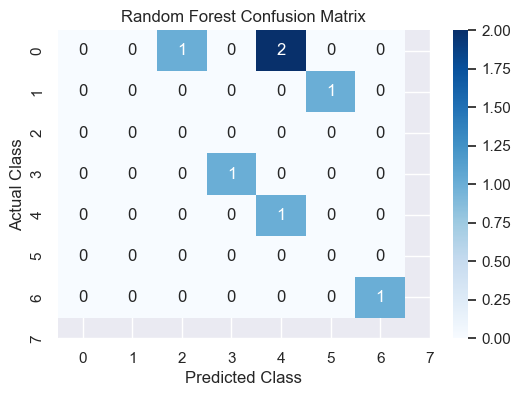

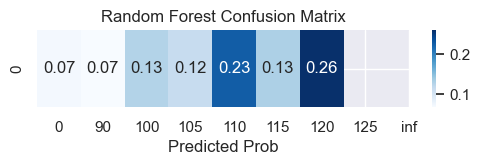

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6], got [1 2 3 4 5 6 7]

In [48]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=bins)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [49]:
target = "Opp_PTS_C"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [50]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [51]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

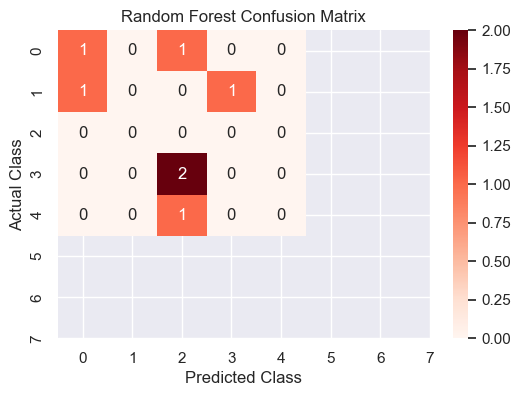

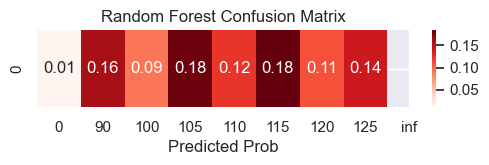

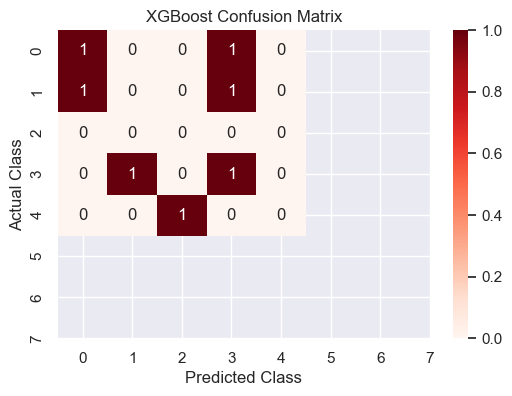

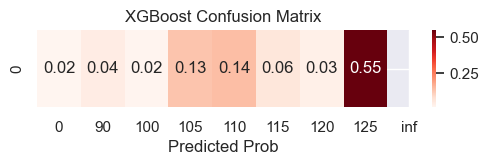

In [52]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=bins)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [53]:
target = "Tm_PTS_C"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [54]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [55]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

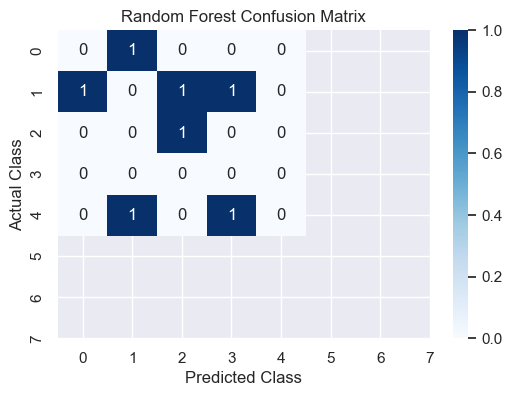

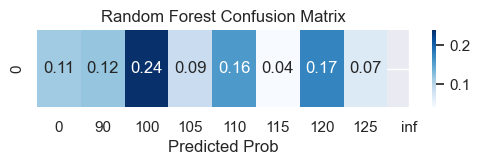

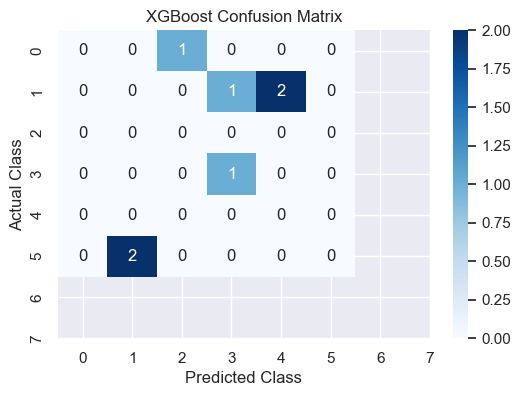

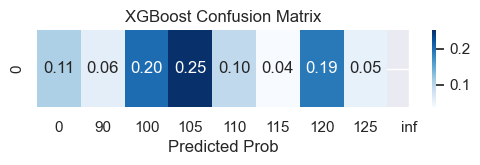

In [56]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=bins)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [57]:
target = "Opp_PTS_C"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [58]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [59]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

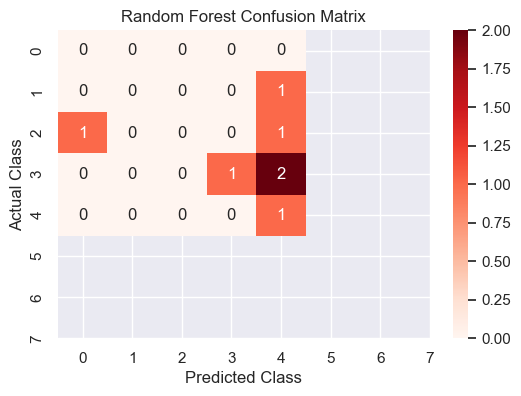

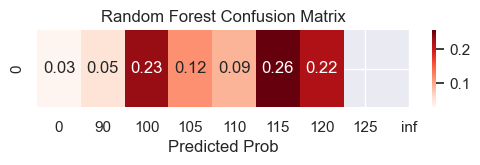

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6], got [1 2 3 4 5 6 7]

In [60]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=bins)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

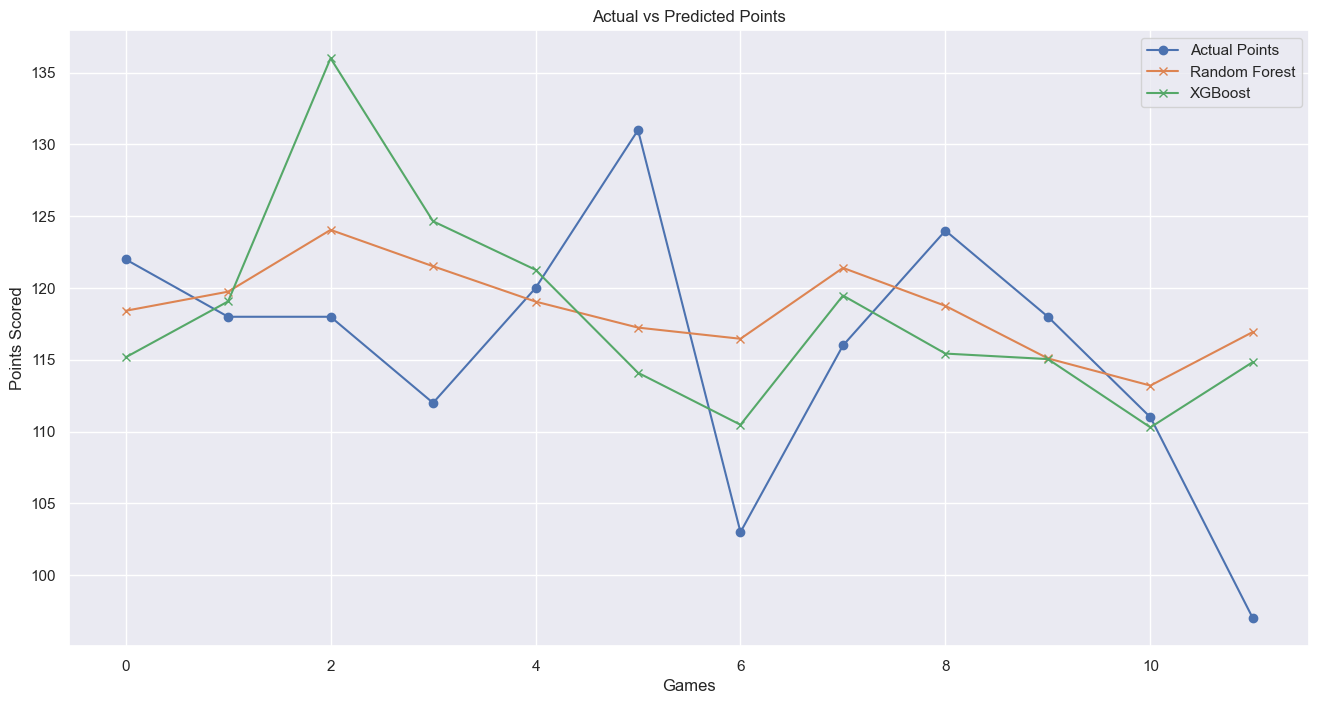

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
